In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os

## Make sure that our RR approximation for Sparse holds in the linear limit

                               mean      variance
parameter                                        
CO (ppm)                   0.998751  2.524936e-04
Heat Index ($^{\circ}$C)   1.112659  2.166603e-03
NO$_2$ (ppb)               1.163608  9.813548e-04
PM$_{10}$ ($\mu$g/m$^3$)   1.034813  3.660277e-04
PM$_{2.5}$ ($\mu$g/m$^3$)  0.959550  1.995277e-04
SO$_2$ (ppb)               0.899602  9.853438e-04
SVI (%)                    1.221479  1.922985e-03
Precipitation (mm)         1.000219  1.572432e-07
                               mean      variance
parameter                                        
CO (ppm)                   0.998803  2.516943e-04
Heat Index ($^{\circ}$C)   1.113150  2.162280e-03
NO$_2$ (ppb)               1.163680  9.807033e-04
PM$_{10}$ ($\mu$g/m$^3$)   1.034929  3.661241e-04
PM$_{2.5}$ ($\mu$g/m$^3$)  0.959619  1.997860e-04
SO$_2$ (ppb)               0.899702  9.855653e-04
SVI (%)                    1.221558  1.923738e-03
Precipitation (mm)         1.000215  1.486651e-07


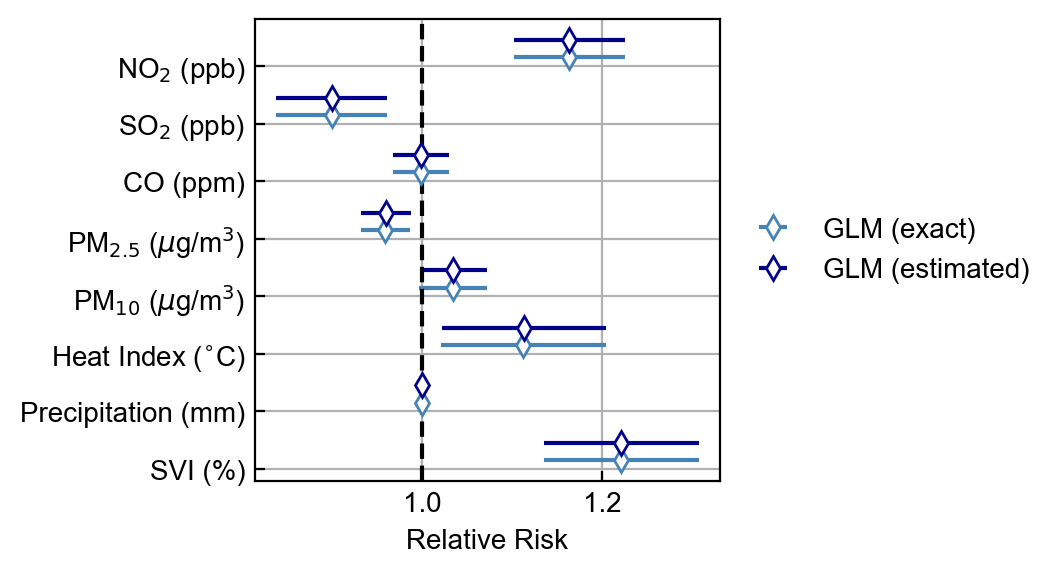

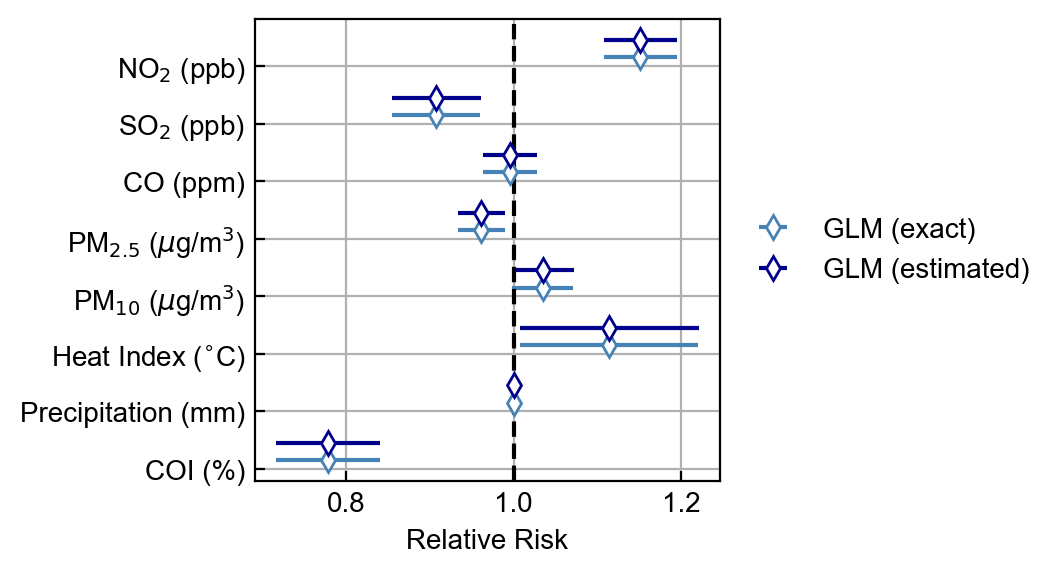

In [3]:
from airquality.analysis.plotting import plot_effect, labels_map
from airquality.analysis.postprocessing import aggregate_effects

svi_map = {
    'NO$_2$ (ppb)': 7,
    'SO$_2$ (ppb)': 6,
    'CO (ppm)': 5,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 4,
    'PM$_{10}$ ($\mu$g/m$^3$)': 3,
    'Heat Index ($^{\circ}$C)': 2,
    'Precipitation (mm)': 1,
    'SVI (%)': 0,
}

coi_map = {
    'NO$_2$ (ppb)': 7,
    'SO$_2$ (ppb)': 6,
    'CO (ppm)': 5,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 4,
    'PM$_{10}$ ($\mu$g/m$^3$)': 3,
    'Heat Index ($^{\circ}$C)': 2,
    'Precipitation (mm)': 1,
    'COI (%)': 0,
}

folders = [
    'GLM/base',
    'GLM/base',
]
labels = ['GLM (exact)', 'GLM (estimated)']
colors = ['steelblue', 'darkblue']
mean = ['risk_ratio', 'risk_ratio (est.)']
ci = [
    ['lower_ci', 'upper_ci'],
    ['lower_ci (est.)', 'upper_ci (est.)'],
]


for socio_var, ticks_map in zip(['svi', 'coi'], [svi_map, coi_map]):
    fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
    N = len(folders)
    dodge = 0.15
    offset = -dodge
    dodge_step = (2 * dodge) / (N - 1)
    for ii, (folder, label, color) in enumerate(zip(folders, labels, colors)):
        offset += dodge_step
        risk_df = aggregate_effects(
            os.path.join(os.environ["MODELS_DIR"], socio_var, folder), 
            mean_column=mean[ii], 
            ci_columns=ci[ii],
            overwrite=True)
        plot_effect(ax, risk_df, labels_map=labels_map, ticks_map=ticks_map, label=label, color=color, offset=offset)
        print(risk_df.dropna().set_index('parameter'))

    ax.axvline(1, color='black', linestyle='--')
    ax.set_xlabel('Relative Risk')
    ax.legend(loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0);